In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os
import numpy as np
import matplotlib.pyplot as plt
from trianglechain import TriangleChain

from msfm.utils import files, parameters
from msi.utils import plotting

# load existing chains

In [58]:
conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v14/extended.yaml")

In [32]:
# mock = "Buzzard_0"
mock = "Buzzard_3"
# mock = "Buzzard_7"

# base_dir = "/pscratch/sd/a/athomsen/run_files/v14/extended"
base_dir = "/global/cfs/cdirs/des/athomsen/deep_lss/run_files/v14/extended"

steps = 400_000
network_dir = os.path.join(base_dir, f"lensing/mutual_info/2025-04-19_18-54-31_deepsphere_default/{steps}_steps_likelihood_sigmoid")
wl_chain = np.load(os.path.join(network_dir, f"likelihood_flow/chain_{mock}.npy"))
wl_params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta"]

steps = 240_000
network_dir = os.path.join(base_dir, f"clustering/mutual_info/2025-05-14_23-10-45_deepsphere_default/{steps}_steps_likelihood_sigmoid")
gc_chain = np.load(os.path.join(network_dir, f"likelihood_flow/chain_{mock}.npy"))
gc_params = ["Om", "s8", "w0", "bg1", "bg2", "bg3", "bg4"]

steps = 400_000
network_dir = os.path.join(base_dir, f"combined/mutual_info/2025-04-30_02-27-42_deepsphere_default/{steps}_steps_likelihood_sigmoid")
cp_chain = np.load(os.path.join(network_dir, f"likelihood_flow/chain_{mock}.npy"))
cp_params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta", "bg1", "bg2", "bg3", "bg4"]


# plot

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

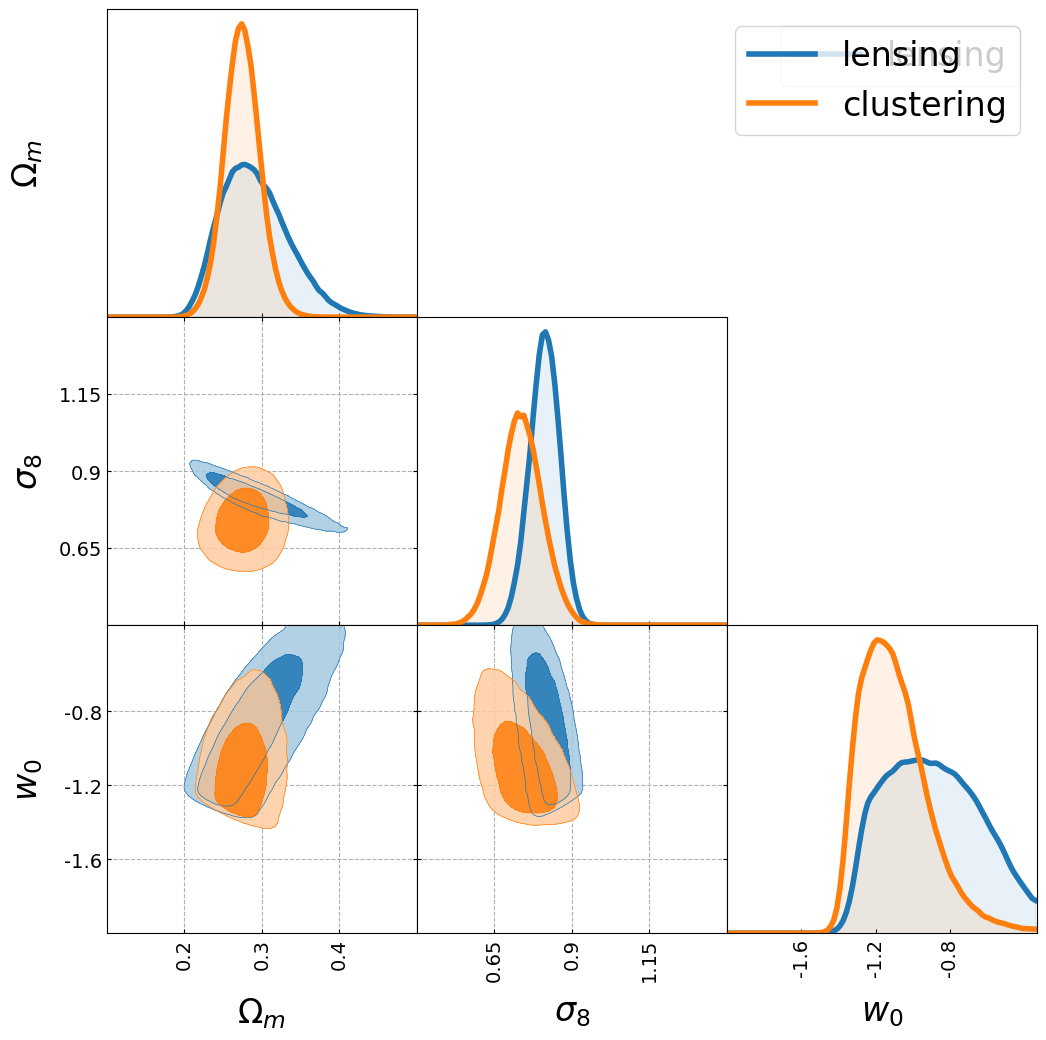

In [33]:
# all_params = cp_params
all_params = ["Om", "s8", "w0"]

ranges = dict(zip(all_params, parameters.get_prior_intervals(all_params, conf=conf)))
param_label_dict = plotting.param_label_dict

tri = TriangleChain(
    params=all_params,
    ranges=ranges,
    fill=True,
    grid=True,
    show_legend=True,
    labels=[param_label_dict[param] for param in all_params],
)

tri.contour_cl(wl_chain, names=wl_params, label="lensing");
tri.contour_cl(gc_chain, names=gc_params, label="clustering");
# tri.contour_cl(cp_chain, names=cp_params, label="combined");

# tensiometer

In [3]:
# based on https://tensiometer.readthedocs.io/en/latest/example_non_gaussian_tension.html
# https://arxiv.org/abs/2105.03324

import getdist
from getdist.mcsamples import MCSamples

import tensiometer
from tensiometer.utilities import stats_utilities as utilities
from tensiometer import mcmc_tension

In [4]:
wl_samples = MCSamples(samples=wl_chain, names=wl_params)
gc_samples = MCSamples(samples=gc_chain, names=gc_params)
# wl_samples = MCSamples(samples=wl_chain[::100], names=wl_params)
# gc_samples = MCSamples(samples=gc_chain[::100], names=gc_params)

diff_chain = mcmc_tension.parameter_diff_chain(wl_samples, gc_samples, boost=4)

NameError: name 'wl_chain' is not defined

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

(<Figure size 1200x1200 with 9 Axes>,
 array([[<Axes: ylabel='delta_Om'>, <Axes: >, <Axes: >],
        [<Axes: ylabel='delta_s8'>, <Axes: >, <Axes: >],
        [<Axes: xlabel='delta_Om', ylabel='delta_w0'>,
         <Axes: xlabel='delta_s8'>, <Axes: xlabel='delta_w0'>]],
       dtype=object))

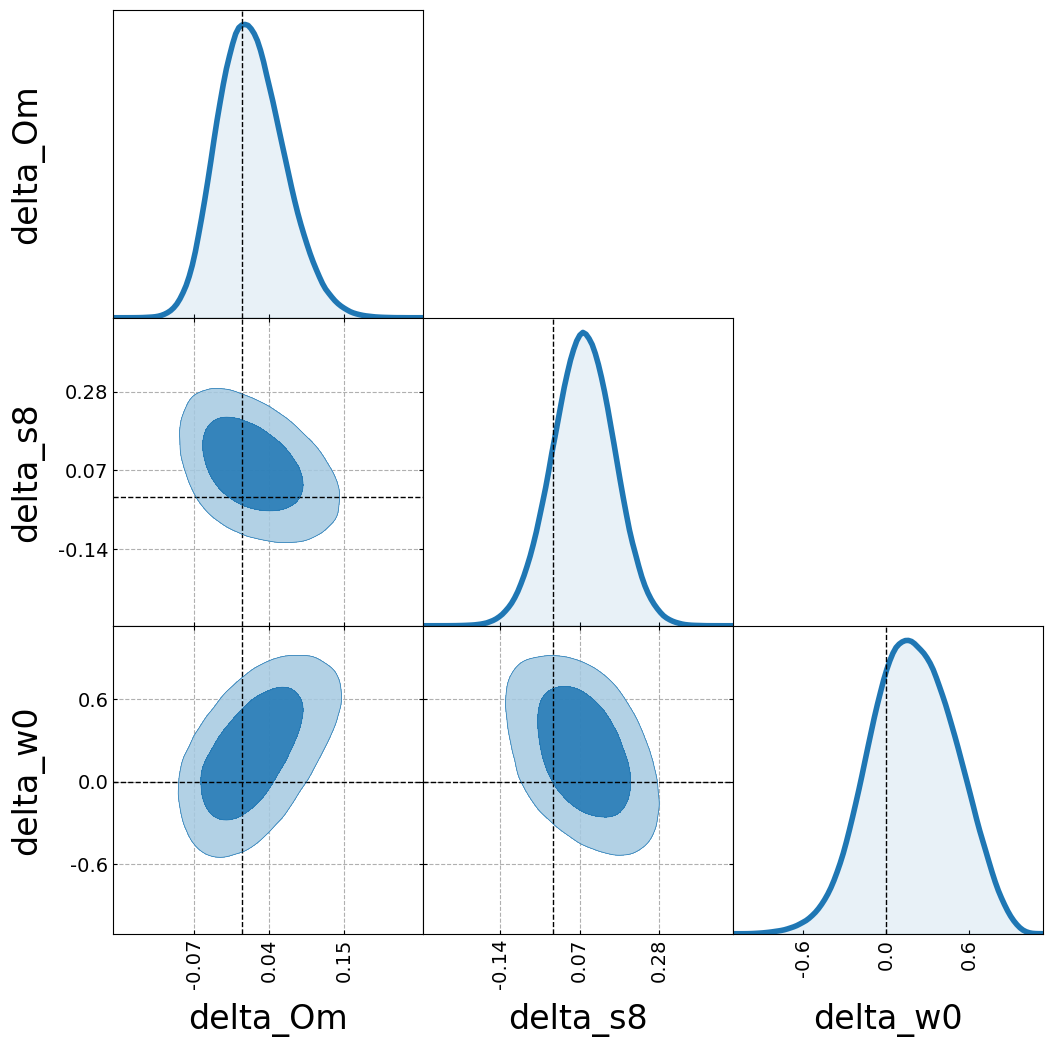

In [36]:
samples = diff_chain.samples
params = [p.name for p in diff_chain.paramNames.names]

tri = TriangleChain(
    params=params,
    fill=True,
    grid=True,
    labels=params,
    axlines_kwargs={"linestyle": "--", "lw": 1},
)

tri.contour_cl(samples, names=params);
tri.axlines(np.zeros((1,len(params))), names=params, color="k")

In [12]:
shift_P, shift_low, shift_hi = mcmc_tension.kde_parameter_shift(diff_chain, scale='MISE', feedback=10)
# shift_P, shift_low, shift_hi = mcmc_tension.kde_parameter_shift(diff_chain, scale='MISE', feedback=10, method="brute_force")

# print the results:
print(f'Shift probability considering all parameters:\n',
      f'   P = {shift_P:.5f} +{shift_hi-shift_P:.5f} -{shift_P-shift_low:.5f}')
# turn the result to effective number of sigmas:
print(f'    n_sigma = {utilities.from_confidence_to_sigma(shift_P):.3f}',
      f'+{utilities.from_confidence_to_sigma(shift_hi)-utilities.from_confidence_to_sigma(shift_P):.3f}',
      f'-{utilities.from_confidence_to_sigma(shift_P)-utilities.from_confidence_to_sigma(shift_low):.3f}')

Dimension       : 3
N    samples    : 4096000
Neff samples    : 4096000.00
Smoothing scale : [0.012 0.012 0.012]
Building KD-Tree with leafsize = 400
Neighbours elimination
neighbor_elimination: chunk 1
    surviving elements 3043 of 4096000
neighbor_elimination: chunk 2
    surviving elements 2989 of 4096000
neighbor_elimination: chunk 3
    surviving elements 2981 of 4096000
neighbor_elimination: polishing


100%|##########| 2981/2981 [10:00<00:00,  4.97it/s]


    surviving elements 2978 of 4096000
KDE method: neighbor_elimination
Time taken for KDE calculation: 673.3 (s)
Shift probability considering all parameters:
    P = 0.99927 +0.00001 -0.00001
    n_sigma = 3.379 +0.005 -0.005


# joint sampling for correlated observables 

In [4]:
from msfm.utils import files
from msi.utils import preprocessing
from msi.flow_conductor.likelihood_flow import LikelihoodFlow
from msi.flow_conductor.marginal_flow import MarginalFlow
from msi.utils.mlp import MLP

from getdist.mcsamples import MCSamples
from tensiometer import mcmc_tension

conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v14/extended.yaml")
params = ["Om", "s8", "w0"]

### v14

In [5]:
# young-serenity-1089 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/3g0z8qob/overview)
wl_dir = "/pscratch/sd/a/athomsen/run_files/v14/extended/lensing/mutual_info/2025-04-19_18-54-31_deepsphere_default"
n_steps = 400_000

_, wl_preds, wl_cosmos, wl_dict = preprocessing.get_reshaped_network_preds(
    wl_dir,
    n_steps=n_steps,
    with_fidu=False,
)

wl_cosmos = wl_cosmos[:,:3]

wl_model = LikelihoodFlow(
    params, 
    conf, 
    feature_dim=wl_preds.shape[-1],
    out_dir=wl_dir,
    label=f"cosmo_params",
    load_existing=True,
)

# wl_model.fit(
#     x=wl_preds,
#     theta=wl_cosmos,
#     batch_size=10_000,
#     scheduler_type="cosine",
#     save_model=True,
# )

26-01-26 02:46:35 input_output INF   Loading predictions from /pscratch/sd/a/athomsen/run_files/v14/extended/lensing/mutual_info/2025-04-19_18-54-31_deepsphere_default/preds_400000.h5 
26-01-26 02:46:35 input_output INF   Array shapes: 
26-01-26 02:46:35 input_output INF   fiducial/vali/pred = (40000, 12) 
26-01-26 02:46:35 input_output INF   fiducial/vali/i_example = (40000,) 
26-01-26 02:46:35 input_output INF   fiducial/vali/i_noise = (40000,) 
26-01-26 02:46:35 input_output INF   grid/pred          = (2500, 80, 12) 
26-01-26 02:46:35 input_output INF   grid/cosmo         = (2500, 80, 6) 
26-01-26 02:46:35 input_output INF   grid/i_example     = (2500, 80) 
26-01-26 02:46:35 input_output INF   grid/i_noise       = (2500, 80) 
26-01-26 02:46:35 input_output INF   grid/i_sobol       = (2500, 80) 


26-01-26 02:46:35 preprocessin INF   Shapes after concatenation and selection: 
26-01-26 02:46:35 preprocessin INF   grid_preds  = (200000, 12) 
26-01-26 02:46:35 preprocessin INF   grid_co

/global/u2/a/athomsen/multiprobe-simulation-inference/msi/flow_conductor/likelihood_flow.py:495: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.loa

In [6]:
# classic-frost-1096 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/fp2vxm07/overview)
gc_dir = "/pscratch/sd/a/athomsen/run_files/v14/extended/clustering/mutual_info/2025-05-14_23-10-45_deepsphere_default"
n_steps = 240_000

_, gc_preds, gc_cosmos, gc_dict = preprocessing.get_reshaped_network_preds(
    gc_dir,
    n_steps=n_steps,
    with_fidu=False,
)

gc_cosmos = gc_cosmos[:,:3]

gc_model = LikelihoodFlow(
    params, 
    conf, 
    feature_dim=gc_preds.shape[-1],
    out_dir=gc_dir,
    label=f"cosmo_params",
    load_existing=True,
)

# gc_model.fit(
#     x=gc_preds,
#     theta=gc_cosmos,
#     batch_size=10_000,
#     scheduler_type="cosine",
#     save_model=True,
# )

26-01-26 02:46:36 input_output INF   Loading predictions from /pscratch/sd/a/athomsen/run_files/v14/extended/clustering/mutual_info/2025-05-14_23-10-45_deepsphere_default/preds_240000.h5 
26-01-26 02:46:36 input_output INF   Array shapes: 
26-01-26 02:46:36 input_output INF   fiducial/vali/pred = (40000, 14) 
26-01-26 02:46:36 input_output INF   fiducial/vali/i_example = (40000,) 
26-01-26 02:46:36 input_output INF   fiducial/vali/i_noise = (40000,) 
26-01-26 02:46:36 input_output INF   grid/pred          = (2500, 80, 14) 
26-01-26 02:46:36 input_output INF   grid/cosmo         = (2500, 80, 7) 
26-01-26 02:46:36 input_output INF   grid/i_example     = (2500, 80) 
26-01-26 02:46:36 input_output INF   grid/i_noise       = (2500, 80) 
26-01-26 02:46:36 input_output INF   grid/i_sobol       = (2500, 80) 


26-01-26 02:46:36 preprocessin INF   Shapes after concatenation and selection: 
26-01-26 02:46:36 preprocessin INF   grid_preds  = (200000, 14) 
26-01-26 02:46:36 preprocessin INF   grid

In [7]:
mock = "Buzzard_0"
# mock = "Buzzard_3"
wl_obs = wl_dict[f"mocks/pred/{mock}"]
gc_obs = gc_dict[f"mocks/pred/{mock}"]
joint_obs = np.concatenate([wl_obs, gc_obs], axis=0)

## assumption: $s_{wl}$ and $s_{gc}$ are uncorrelated

In [8]:
wl_chain = wl_model.sample_posterior(
    wl_obs,
)

gc_chain = gc_model.sample_posterior(
    gc_obs,
)

delta_chain_ind = mcmc_tension.parameter_diff_chain(
    MCSamples(samples=wl_chain, names=params), 
    MCSamples(samples=gc_chain, names=params), 
    boost=4
).samples

26-01-26 02:46:39 likelihood_f INF   Sampling the posterior from a single observation 
26-01-26 02:46:39      mcmc.py INF   Initial values in prior: 100.0% 
26-01-26 02:46:39      mcmc.py INF   Starting the burn in MCMC chain (1000 steps) 


100%|██████████| 1000/1000 [00:22<00:00, 43.82it/s]

26-01-26 02:47:03      mcmc.py INF   Starting the main MCMC chain (1000 steps) 



100%|██████████| 1000/1000 [00:22<00:00, 44.73it/s]

26-01-26 02:47:25      mcmc.py INF   MAP parameters: {'Om': np.float64(0.313), 's8': np.float64(0.817), 'w0': np.float64(-0.868)} 
26-01-26 02:47:25      mcmc.py INF   Saved the MCMC chain to /pscratch/sd/a/athomsen/run_files/v14/extended/lensing/mutual_info/2025-04-19_18-54-31_deepsphere_default/cosmo_params/likelihood_flow/chain.npy 
26-01-26 02:47:25 likelihood_f INF   Sampling the posterior from a single observation 
26-01-26 02:47:25      mcmc.py INF   Initial values in prior: 100.0% 
26-01-26 02:47:25      mcmc.py INF   Starting the burn in MCMC chain (1000 steps) 



100%|██████████| 1000/1000 [00:25<00:00, 39.25it/s]

26-01-26 02:47:51      mcmc.py INF   Starting the main MCMC chain (1000 steps) 



100%|██████████| 1000/1000 [00:25<00:00, 39.16it/s]

26-01-26 02:48:17      mcmc.py INF   MAP parameters: {'Om': np.float64(0.279), 's8': np.float64(0.479), 'w0': np.float64(-0.333)} 
26-01-26 02:48:17      mcmc.py INF   Saved the MCMC chain to /pscratch/sd/a/athomsen/run_files/v14/extended/clustering/mutual_info/2025-05-14_23-10-45_deepsphere_default/cosmo_params/likelihood_flow/chain.npy 


# correlated

### train emulators

Training: 100%|██████████| 30/30 [00:33<00:00,  1.10s/it, train_loss=2.104521, val_loss=2.107171]


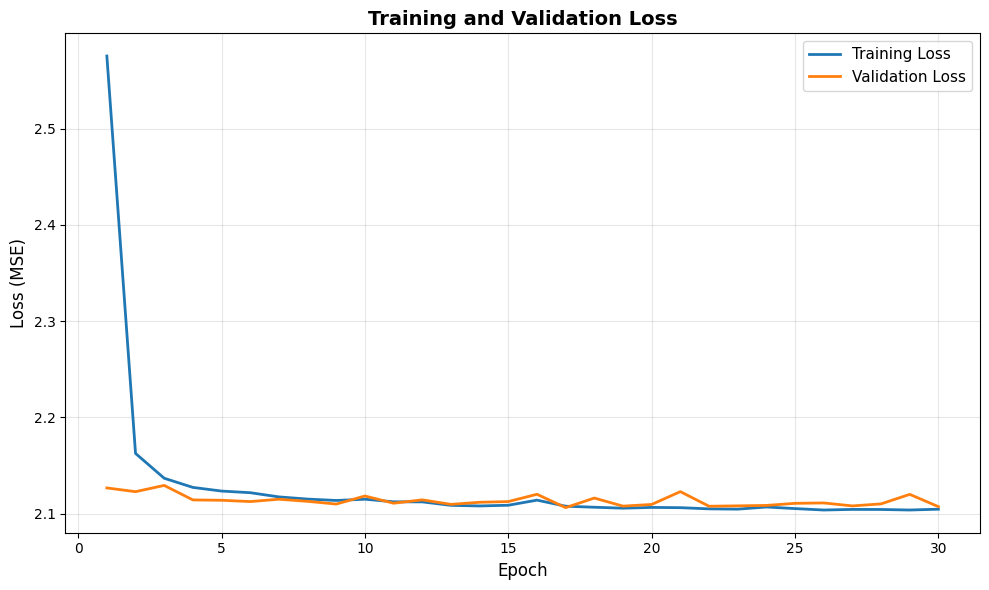

In [9]:
wl_model = MLP(
    input_dim=wl_cosmos.shape[-1], 
    hidden_dims=[512]*2, 
    output_dim=wl_preds.shape[-1], 
    dropout=0.1, 
    use_layer_norm=True
)

wl_history = wl_model.fit(
    wl_cosmos, 
    wl_preds, 
    num_epochs=30,
    batch_size=1_000, 
    learning_rate=1e-3, 
    clip_grad_norm=1.0, 
    validation_split=0.1,
    plot_history=True,
    device="cuda",
)


Training: 100%|██████████| 30/30 [00:33<00:00,  1.10s/it, train_loss=5.751326, val_loss=5.759218]


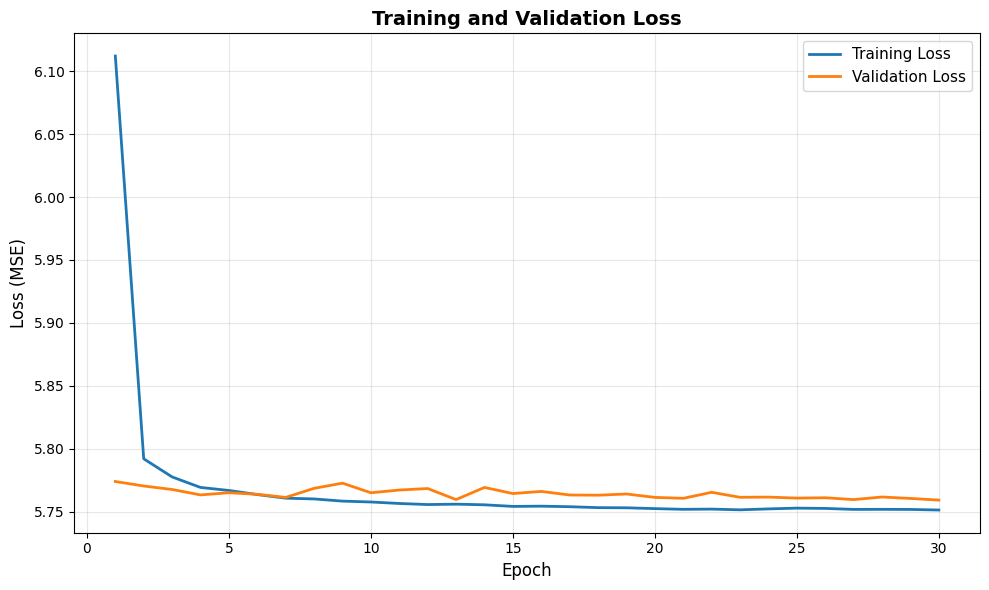

In [10]:
gc_model = MLP(
    input_dim=gc_cosmos.shape[-1], 
    hidden_dims=[512]*2, 
    output_dim=gc_preds.shape[-1], 
    dropout=0.1, 
    use_layer_norm=True
)

gc_history = gc_model.fit(
    gc_cosmos, 
    gc_preds, 
    num_epochs=30,
    batch_size=1_000, 
    learning_rate=1e-3, 
    clip_grad_norm=1.0, 
    validation_split=0.1,
    plot_history=True,
    device="cuda",
)


In [11]:
residuals = np.concatenate(
    [wl_preds - wl_model.predict(wl_cosmos), gc_preds - gc_model.predict(gc_cosmos)], 
    axis=1
)

### train marginal flow

26-01-26 02:49:39 marginal_flo INF   Initialized MarginalFlow with 26D, 5 transforms 
26-01-26 02:49:39 marginal_flo INF   Running on device: cuda 
26-01-26 02:49:39 marginal_flo INF   Using cosine annealing scheduler: lr 1.00e-03 -> 1.00e-06 
26-01-26 02:49:39 marginal_flo INF   Using early stopping with patience=10, min_delta=0.0001 
100%|████████████████████████████|   | 50/50 [01:27<00:00,  1.76s/it]         Epoch 50/50 - lr: 1.00e-06, train_loss: 20.952, vali_loss: 21.379: 
26-01-26 02:51:07 marginal_flo INF   Training complete. Final train_loss: 20.952, vali_loss: 21.379 


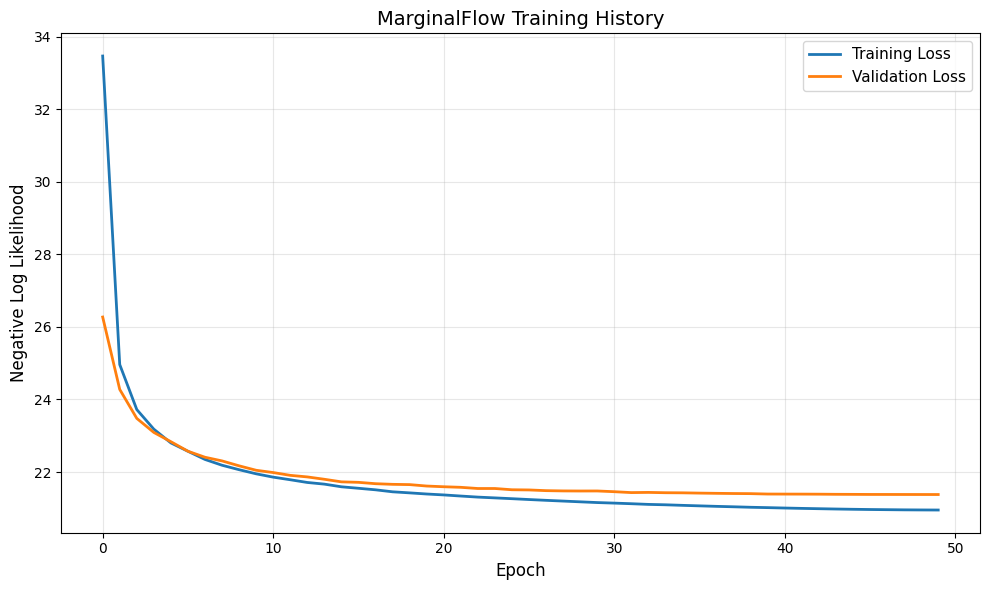

In [13]:
flow = MarginalFlow(
    feature_dim=residuals.shape[-1],
    n_transforms=5,
    hidden_features=128,
    n_blocks=2,
)

history = flow.fit(
    x=residuals,
    n_epochs=50,
    batch_size=4_096,
    vali_split=0.1,
    learning_rate=1e-3,
    clip_by_global_norm=1.0,
    n_patience_epochs=10,
    min_delta=1e-4,
)


### sample residual posterior

In [14]:
residual_samples = flow.sample_residual_posterior(
    x_obs=joint_obs,
    params_wl=params,
    params_gc=params,
    emulator_wl=wl_model,
    emulator_gc=gc_model,
    conf=conf,
    device="cuda",
)

delta_chain_dep = residual_samples[:,:3] - residual_samples[:,3:]

26-01-26 02:51:10      mcmc.py INF   Initial values in prior: 100.0% 
26-01-26 02:51:10      mcmc.py INF   Starting the burn in MCMC chain (1000 steps) 


100%|██████████| 1000/1000 [00:17<00:00, 55.97it/s]

26-01-26 02:51:28      mcmc.py INF   Starting the main MCMC chain (1000 steps) 



100%|██████████| 1000/1000 [00:17<00:00, 56.13it/s]

26-01-26 02:51:46      mcmc.py INF   MAP parameters: {'Om': np.float64(0.299), 's8': np.float64(0.513), 'w0': np.float64(-0.339)} 
26-01-26 02:51:46      mcmc.py WAR   Not saving the MCMC chain 


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

(<Figure size 1200x1200 with 9 Axes>,
 array([[<Axes: ylabel='Om'>, <Axes: >, <Axes: >],
        [<Axes: ylabel='s8'>, <Axes: >, <Axes: >],
        [<Axes: xlabel='Om', ylabel='w0'>, <Axes: xlabel='s8'>,
         <Axes: xlabel='w0'>]], dtype=object))

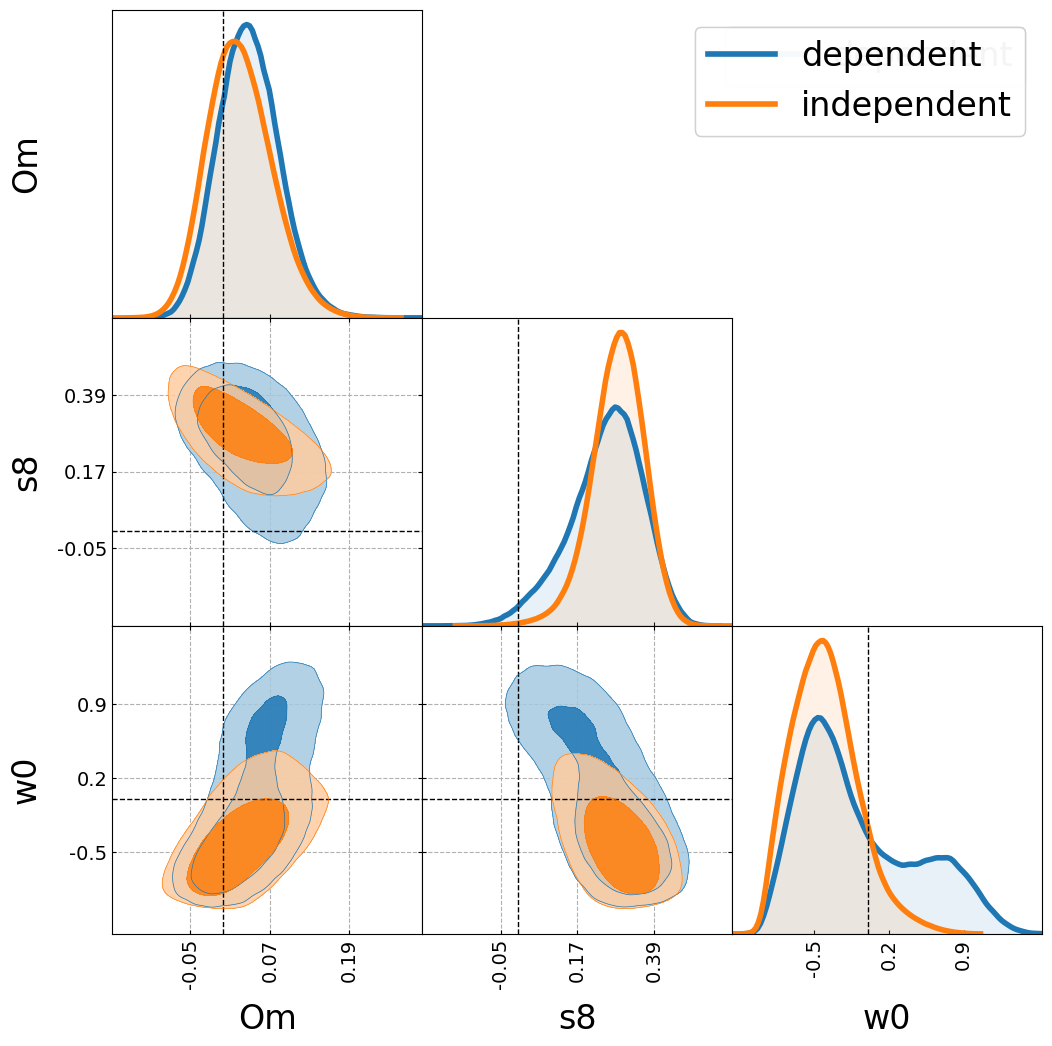

In [15]:
tri = TriangleChain(
    params=params,
    fill=True,
    grid=True,
    show_legend=True,
    labels=params,
    axlines_kwargs={"linestyle": "--", "lw": 1},
)

tri.contour_cl(delta_chain_dep, names=params, label="dependent")
tri.contour_cl(delta_chain_ind, names=params, label="independent")
tri.axlines(np.zeros((1,len(params))), names=params, color="k")